tensor([[-0.4352],
        [-0.0832],
        [ 0.1276],
        ...,
        [ 0.5901],
        [ 0.2343],
        [-0.0578]])
tensor(1.3807, grad_fn=<MseLossBackward0>)
tensor(0.9057, grad_fn=<MseLossBackward0>)
tensor(0.9057, grad_fn=<MseLossBackward0>)


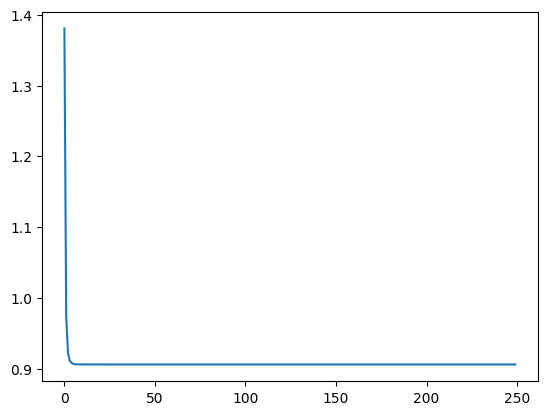

tensor([[66106.0312],
        [66750.2031],
        [61758.0156]], grad_fn=<AddBackward0>)


In [8]:
import sys
import os
import pandas as pd
import torch
from torch import nn
import matplotlib.pyplot as plt

# Pandas: Reading the data
df = pd.read_csv('./data/used_cars.csv')

# Pandas: Preparing the data
age = df["model_year"].max() - df["model_year"]

milage = df['milage']
milage = milage.str.replace( ",", "" )
milage = milage.str.replace( "mi.", "" )
milage = milage.astype(int)

price = df["price"]
price = price.str.replace("$", "")
price = price.str.replace(",", "")
price = price.astype(int)

accident_free = df["accident"] == "None reported"
accident_free.astype(int)

# model폴더가 없다면 새로 만들기
if not os.path.isdir("./model"):
    os.mkdir("./model")

# pandas의 열 값은 tensor가 아니므로 tensor로 변경해줘야 함
# 여러 개의 특성은 열 벡터로 쌓아야 하므로 .column_stack()을 사용해야 함
X = torch.column_stack([
    torch.tensor( accident_free, dtype=torch.float32 ),
    torch.tensor( age, dtype=torch.float32 ),
    torch.tensor( milage, dtype=torch.float32 )
])

# 입력 정규화
X_mean = X.mean(axis=0)
X_std = X.std(axis=0)
torch.save( X_mean, "./model/X_mean.pt" )
torch.save( X_std, "./model/X_std.pt" )
X = ( X - X_mean ) / X_std

# 예측값 텐서에 넣기
# 1행에 수많은 값이 들어가 있는 tensor형태로 우리가 원하는 열벡터가 아님
# y = torch.tensor( price, dtype=torch.float32 )
# y = torch.tensor( price, dtype=torch.float32 ).reshape( (X.size()[0], 1) )
y = torch.tensor( price, dtype=torch.float32 )\
    .reshape( (-1, 1) ) #자동으로 몇 행인지 맞춰줌

# 예상값(출력) 정규화
y_mean = y.mean() # 평균
y_std = y.std() # 표준편차
torch.save( y_mean, "./model/y_mean.pt" )
torch.save( y_std, "./model/y_std.pt" )
y = (y-y_mean) / y_std
print(y)


# 어떠한 종류의 모델을 만들어야 할까? 어떤 특성이 가중치와 연관있을까?

# 모델 생성: 2개의 특성이 입력되고 1개(예측값)가 출력되는 선형 모델
model = nn.Linear( 3, 1 ) # 입력: 마일리지, 연식
loss_fn = torch.nn.MSELoss()
optimizer = torch.optim.SGD( model.parameters(), lr=0.2 )

losses = []

#훈련
for i in range( 0, 250 ):
    optimizer.zero_grad()
    outputs = model( X )
    loss = loss_fn( outputs, y )
    loss.backward()
    optimizer.step()
    
    losses.append( loss.item() )
    
    if i % 100 == 0:
        print( loss )
    
    # if i % 100 == 0:
        # print( loss.item() )
        # print( f'bias:  {model.bias}' )
        # print( f'weight: {model.weight}' )
        # print('----')

plt.plot( losses )
plt.show()

torch.save( model.state_dict(), "./model/model.pt" )

# 테스트 해보기
X_data_accident = torch.tensor([
    [ 0, 5, 10000 ],
    [ 0, 2, 10000 ],
    [ 0, 5, 20000 ]
], dtype = torch.float32 )
prediction_accident = model( (X_data_accident - X_mean) / X_std )
print( prediction_accident * y_std + y_mean )
